In [1]:
import os
import numpy as np
import pandas as pd
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score
from tabpfn import TabPFNClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# Setup Logging
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s [%(name)s] [%(levelname)s] %(message)s', 
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger("LOAO_Unified_Benchmark")

/home/gabriel/miniconda3/envs/diva/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def extract_base_dataset_name(dataname):
    if "_vs_" in dataname:
        part1 = dataname.split("_vs_")[0]
        return part1.rsplit("_", 1)[0]
    return dataname

In [3]:
def prepare_benchmark_data(db_path, seed, split_target='Is_Poisoned'):
    """
    Standardized data loading, filtering, and train-test splitting 
    (mimicking the original classification benchmark approach).
    """
    df = pd.read_csv(db_path)
    df['BaseGroup'] = df['Data'].apply(extract_base_dataset_name)

    # feature_noise_svm is considered clean
    df.loc[df['Method'] == 'feature_noise_svm', 'Is_Poisoned'] = 0
    df.loc[df['Method'] == 'feature_noise_svm', 'Method'] = 'clean'
    
    drop_cols = ['Data', 'Path', 'Method', 'Rate', 'Is_Poisoned', 'error', 'BaseGroup']
    drop_cols += [c for c in df.columns if c in ['Train.Clean', 'Test.Clean', 'Train.Poison', 'Test.Poison']]
    feature_cols = [c for c in df.columns if c not in drop_cols]
    
    logger.info(f"Using all {len(feature_cols)} available features.")

    df[feature_cols] = df[feature_cols].fillna(0)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(gss.split(df[feature_cols], df[split_target], df['BaseGroup']))
    
    train_df_full = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    # Leave out specific poisoners as defined in classification
    poisoner_to_leave_out = ["diva_attack_xgb", "diva_attack", "diva_attack2"]
    train_df_full = train_df_full[~(train_df_full['Method'].isin(poisoner_to_leave_out))]
    test_df = test_df[~(test_df['Method'].isin(poisoner_to_leave_out))]

    # Identify methods
    poisoners = sorted([m for m in train_df_full['Method'].unique() if m != 'clean'])
    all_methods = sorted(list(train_df_full['Method'].unique()))
    
    logger.info(f"Identified {len(poisoners)} poisoners to test: {poisoners}")
    
    return train_df_full, test_df, feature_cols, poisoners, all_methods

In [ ]:
db_path = "meta_db_universal.csv"
workers = 4
seed = 42
binary_model_path = "data/binary_detector.joblib"
plots_dir = f"data/plots_multiclass"
os.makedirs(plots_dir, exist_ok=True)

hard_ood_threshold = 0.60
binary_threshold = 0.76

In [5]:
logger.info(f"--- Starting Two-Stage Cascading Benchmark ---")

if not os.path.exists(binary_model_path):
    logger.error(f"Binary model not found at {binary_model_path}. Please provide a valid path.")

logger.info(f"Loading Binary Detector from {binary_model_path}")
binary_clf = joblib.load(binary_model_path)


# 1. Load Data
train_df_full, test_df, feature_cols, poisoners, all_methods = prepare_benchmark_data(
    db_path, seed, split_target='Method'
)

poisoners = sorted([m for m in train_df_full['Method'].unique() if m != 'clean'])

# 2. Define and Apply Family Mapping
family_mapping = {
    'art_svm': 'Family_SVM',
    'poissvm_svm': 'Family_SVM',
    
    'learning_to_confuse': 'Clean_Label',
    'badnets': 'Clean_Label',
    'metapoison': 'Clean_Label',
    'witches_brew': 'Clean_Label',
    'feature_collision': 'Clean_Label',
    'poison_frogs': 'Clean_Label',
    
    'alfa_svm': 'Label_Flip',
    'random_flip_svm': 'Label_Flip',
    
    'clean': 'clean'
}

train_df_full['Family'] = train_df_full['Method'].map(family_mapping)
test_df['Family'] = test_df['Method'].map(family_mapping)

2026-05-27 14:49:07 [LOAO_Unified_Benchmark] [INFO] --- Starting Two-Stage Cascading Benchmark ---
2026-05-27 14:49:07 [LOAO_Unified_Benchmark] [INFO] Loading Binary Detector from binary_detector.joblib
2026-05-27 14:49:07 [LOAO_Unified_Benchmark] [INFO] Using all 72 available features.
2026-05-27 14:49:07 [LOAO_Unified_Benchmark] [INFO] Identified 10 poisoners to test: ['alfa_svm', 'art_svm', 'badnets', 'feature_collision', 'learning_to_confuse', 'metapoison', 'poison_frogs', 'poissvm_svm', 'random_flip_svm', 'witches_brew']


In [6]:
# =========================================================================
# 3. Full Dataset Evaluation (Baseline - No Holdouts)
# =========================================================================
logger.info(f"🚀 Training Family Classifier: [BASELINE ALL DATA - NO HOLDOUTS]")

train_df_poison = train_df_full[train_df_full['Family'] != 'clean'].copy()
le_all = LabelEncoder()
y_train_all = le_all.fit_transform(train_df_poison['Family'])

clf_multi_all = TabPFNClassifier(n_estimators=32, device='auto', random_state=seed)
clf_multi_all.fit(train_df_poison[feature_cols], y_train_all)

X_test_all = test_df[feature_cols]

# Stage 1: Binary Prediction
bin_probs_all = binary_clf.predict_proba(X_test_all)[:, 1]
bin_preds_all = (bin_probs_all >= binary_threshold).astype(int)

# Stage 2: Multiclass Prediction & OOD
multi_probs_all = clf_multi_all.predict_proba(X_test_all)
multi_preds_all = le_all.inverse_transform(np.argmax(multi_probs_all, axis=1))

2026-05-27 14:49:07 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Family Classifier: [BASELINE ALL DATA - NO HOLDOUTS]


2026-05-27 14:49:48 [LOAO_Unified_Benchmark] [INFO]    => Saved OOD Threshold Curve to data/plots_multiclass/ood_rate_vs_threshold_per_family.png


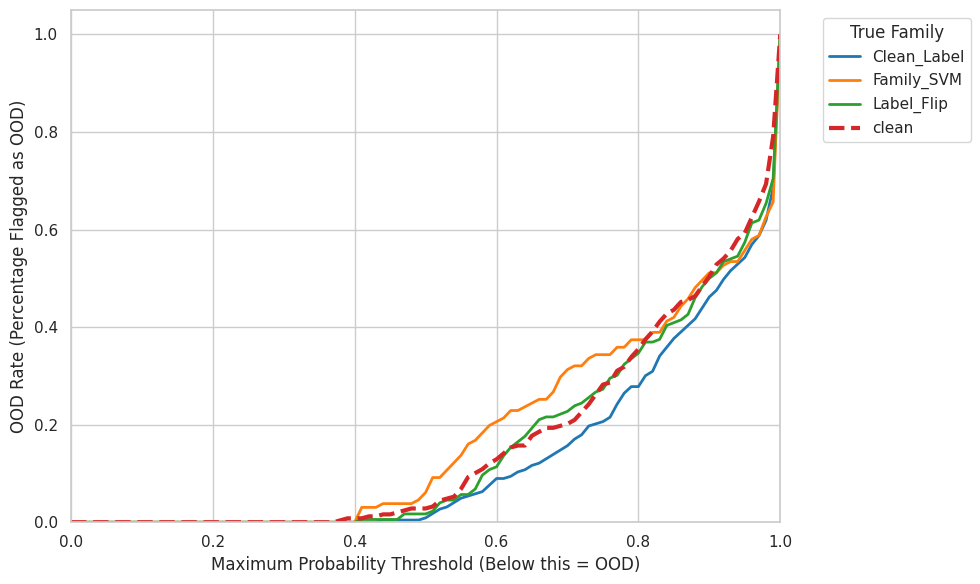

In [7]:
"""
Plots the rate of datasets classified as OOD vs. the Maximum Probability Threshold,
broken down by the true Family (including clean).
"""
# Calculate the maximum predicted probability for each test instance
max_probs = np.max(multi_probs_all, axis=1)

# Define a range of thresholds to test (from 0 to 1 in 0.01 increments)
thresholds = np.linspace(0.0, 1.0, 101)

# Get unique families in the test set
families = sorted([f for f in test_df['Family'].unique() if pd.notna(f)])

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Define a color palette
palette = sns.color_palette("tab10", len(families))

for idx, family in enumerate(families):
    # Isolate the probabilities for just this family
    family_mask = test_df['Family'] == family
    family_max_probs = max_probs[family_mask]
    
    if len(family_max_probs) == 0:
        continue
        
    ood_rates = []
    for t in thresholds:
        # If the max probability is strictly less than the threshold, it is flagged as OOD
        rate = (family_max_probs < t).mean()
        ood_rates.append(rate)
        
    # Highlight 'clean' with a dashed line to differentiate it from attacks
    lw = 3 if family == 'clean' else 2
    ls = '--' if family == 'clean' else '-'
    
    plt.plot(thresholds, ood_rates, label=family, color=palette[idx], linewidth=lw, linestyle=ls)
    
plt.xlabel("Maximum Probability Threshold (Below this = OOD)", fontsize=12)
plt.ylabel("OOD Rate (Percentage Flagged as OOD)", fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)

# Move legend outside the plot
plt.legend(title="True Family", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plot_path = os.path.join(plots_dir, "ood_rate_vs_threshold_per_family.png")
plt.savefig(plot_path, dpi=300)
    
logger.info(f"   => Saved OOD Threshold Curve to {plot_path}")

2026-05-27 14:49:48 [LOAO_Unified_Benchmark] [INFO]    => [ALL DATA] Pipeline Accuracies per Family:
2026-05-27 14:49:48 [LOAO_Unified_Benchmark] [INFO]       - clean: 76.21%
2026-05-27 14:49:48 [LOAO_Unified_Benchmark] [INFO]       - Clean_Label: 72.65%
2026-05-27 14:49:48 [LOAO_Unified_Benchmark] [INFO]       - Family_SVM: 64.89%
2026-05-27 14:49:48 [LOAO_Unified_Benchmark] [INFO]       - Label_Flip: 56.82%


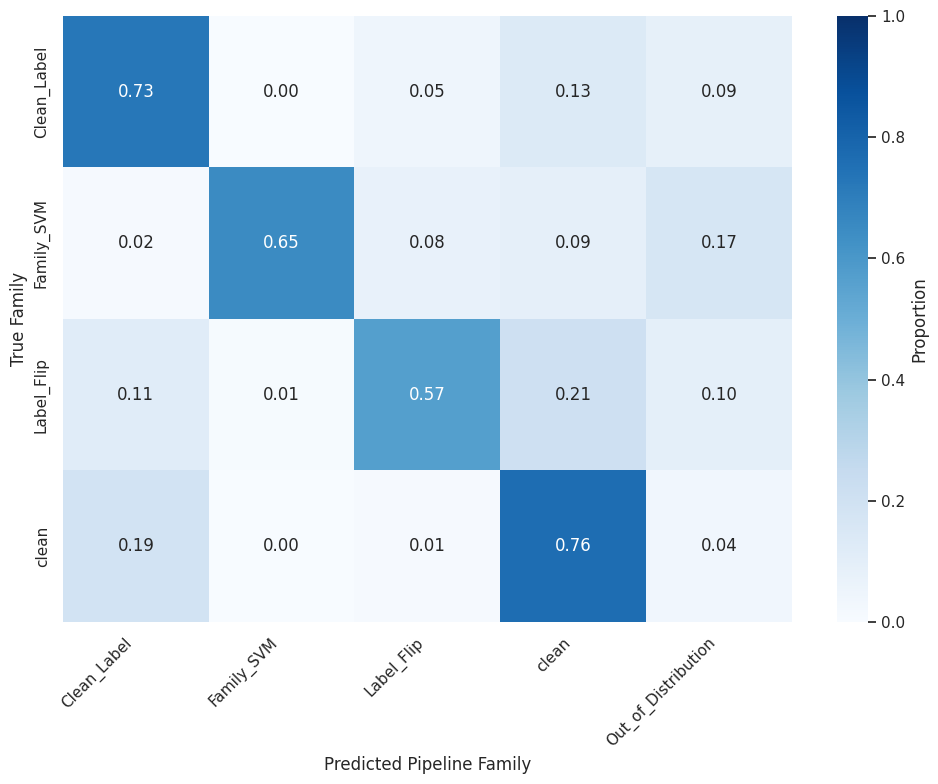

In [8]:
is_ood_all = np.max(multi_probs_all, axis=1) < hard_ood_threshold

test_df_all = test_df.copy()
test_df_all['Pipeline_Prediction'] = np.where(
    bin_preds_all == 0, 
    'clean', 
    np.where(is_ood_all, 'Out_of_Distribution', multi_preds_all)
)

all_data_accs = []
logger.info("   => [ALL DATA] Pipeline Accuracies per Family:")
for family in test_df_all['Family'].unique():
    mask = test_df_all['Family'] == family
    if mask.sum() > 0:
        acc = accuracy_score(test_df_all.loc[mask, 'Family'], test_df_all.loc[mask, 'Pipeline_Prediction'])
        all_data_accs.append({'Family': family, 'Accuracy': acc})
        logger.info(f"      - {family}: {acc:.2%}")
        
df_all_accs = pd.DataFrame(all_data_accs)

# Standard Heatmap Confusion Matrix (Baseline)
# Using crosstab allows us to have asymmetric rows and columns automatically
cm_df_all = pd.crosstab(
    test_df_all['Family'], 
    test_df_all['Pipeline_Prediction'], 
    rownames=['True Family'], 
    colnames=['Predicted Pipeline Family'],
    normalize='index' # Normalizes over rows directly
).fillna(0)

# Ensure standard ordering
expected_true_all = sorted(test_df_all['Family'].unique())
expected_pred_all = expected_true_all + ['Out_of_Distribution']
cm_df_all = cm_df_all.reindex(index=expected_true_all, columns=expected_pred_all, fill_value=0.0)

fig_cm_all, ax_cm_all = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_df_all, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax_cm_all, cbar_kws={'label': 'Proportion'})
plt.setp(ax_cm_all.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
fig_cm_all.savefig(os.path.join(plots_dir, "cascade_cm_all_data.png"), dpi=300)

In [9]:
# =========================================================================
# 4. Zero-Day Generalization & OOD Loop
# =========================================================================
ood_results = []
all_test_preds = [] 

for holdout in poisoners:
    logger.info(f"🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: {holdout.upper()}]")
    
    train_df = train_df_full[(train_df_full['Method'] != holdout) & (train_df_full['Family'] != 'clean')].copy()
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(train_df['Family'])
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    
    clf_multi = TabPFNClassifier(n_estimators=32, device='auto', random_state=seed)
    clf_multi.fit(X_train, y_train_encoded)
    
    bin_probs = binary_clf.predict_proba(X_test)[:, 1]
    bin_preds = (bin_probs >= binary_threshold).astype(int)
    
    multi_probs = clf_multi.predict_proba(X_test)
    multi_preds = le.inverse_transform(np.argmax(multi_probs, axis=1))
    is_ood = np.max(multi_probs, axis=1) < hard_ood_threshold
    
    test_df_copy = test_df.copy()
    test_df_copy['Is_Zero_Day'] = (test_df_copy['Method'] == holdout).astype(int)
    test_df_copy['Holdout'] = holdout

    pipeline_preds = np.where(
        bin_preds == 0, 
        'clean', 
        np.where(is_ood, 'Out_of_Distribution', multi_preds)
    )
    test_df_copy['Pipeline_Prediction'] = pipeline_preds
    
    all_test_preds.append(test_df_copy)
    
    zero_day_df = test_df_copy[test_df_copy['Is_Zero_Day'] == 1]
    
    known_poison_mask = (test_df_copy['Is_Zero_Day'] == 0) & (test_df_copy['Family'] != 'clean')
    known_acc = accuracy_score(
        test_df_copy.loc[known_poison_mask, 'Family'], 
        test_df_copy.loc[known_poison_mask, 'Pipeline_Prediction']
    ) if known_poison_mask.sum() > 0 else 0
    
    zero_day_family_acc = (zero_day_df['Pipeline_Prediction'] == zero_day_df['Family']).mean() if not zero_day_df.empty else 0
    zero_day_ood_rate = (zero_day_df['Pipeline_Prediction'] == 'Out_of_Distribution').mean() if not zero_day_df.empty else 0
    
    clean_mask = test_df_copy['Family'] == 'clean'
    clean_acc = accuracy_score(
        test_df_copy.loc[clean_mask, 'Family'], 
        test_df_copy.loc[clean_mask, 'Pipeline_Prediction']
    ) if clean_mask.sum() > 0 else 0
    
    ood_results.append({
        'Holdout_Poisoner': holdout,
        'True_Macro_Family': family_mapping.get(holdout, 'Unknown'),
        'Known_Poison_Family_Acc': known_acc,
        'Zero_Day_Intra_Family_Acc': zero_day_family_acc,
        'Zero_Day_OOD_Rate': zero_day_ood_rate,
        'Clean_Retention_Acc': clean_acc
    })

2026-05-27 14:49:49 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: ALFA_SVM]
2026-05-27 14:50:26 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: ART_SVM]
2026-05-27 14:51:08 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: BADNETS]
2026-05-27 14:51:50 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: FEATURE_COLLISION]
2026-05-27 14:52:31 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: LEARNING_TO_CONFUSE]
2026-05-27 14:53:13 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: METAPOISON]
2026-05-27 14:53:54 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: POISON_FROGS]
2026-05-27 14:54:36 [LOAO_Unified_Benchmark] [INFO] 🚀 Training Cascade Multiclassifier: [HOLDOUT METHOD: POISSVM_SVM]
2026-05-27 14:55:18 [LOAO_Unified_Benchmark] [INFO] 🚀

2026-05-27 14:56:45 [LOAO_Unified_Benchmark] [INFO]    => Saved textual accuracy table to data/plots_multiclass/holdout_accuracies_table.csv


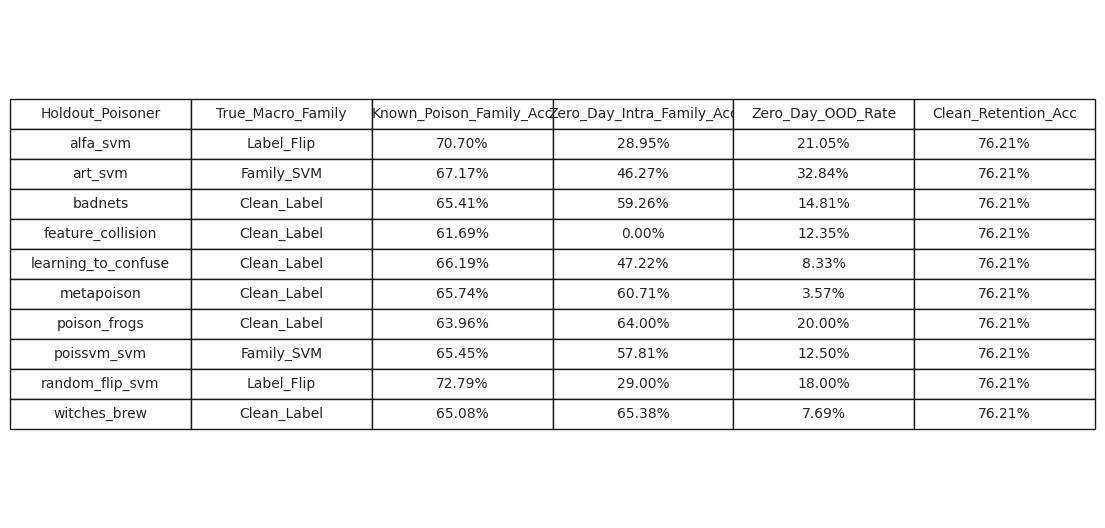

In [10]:
# =========================================================================
# 5. Accuracy Table Generation
# =========================================================================
results_df = pd.DataFrame(ood_results)

paper_table_df = results_df.copy()
metric_cols = ['Known_Poison_Family_Acc', 'Zero_Day_Intra_Family_Acc', 'Zero_Day_OOD_Rate', 'Clean_Retention_Acc']
for col in metric_cols:
    paper_table_df[col] = (paper_table_df[col] * 100).apply(lambda x: f"{x:.2f}%")
    
# Save as CSV
csv_path = os.path.join(plots_dir, "holdout_accuracies_table.csv")
paper_table_df.to_csv(csv_path, index=False)
logger.info(f"   => Saved textual accuracy table to {csv_path}")

# Render an image of the table 
fig_tbl, ax_tbl = plt.subplots(figsize=(14, 0.6 * (len(paper_table_df) + 1)))
ax_tbl.axis('off')
ax_tbl.axis('tight')
tbl = ax_tbl.table(
    cellText=paper_table_df.values, 
    colLabels=paper_table_df.columns, 
    cellLoc='center', 
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 1.8)

tbl_path = os.path.join(plots_dir, "holdout_accuracies_table.png")
fig_tbl.savefig(tbl_path, dpi=300, bbox_inches='tight')